In [65]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/priyangshumukherjee/mental-health-text-classification-dataset/mental_health_combined_test.csv
/kaggle/input/datasets/priyangshumukherjee/mental-health-text-classification-dataset/mental_heath_unbanlanced.csv
/kaggle/input/datasets/priyangshumukherjee/mental-health-text-classification-dataset/mental_heath_feature_engineered.csv
/kaggle/input/datasets/szegeelim/mental-health/Combined Data.csv


In [66]:
!pip -q install transformers datasets accelerate evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 786.3 kB/s eta 0:00:00a 0:00:01


In [67]:
import os
import re
import random
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

import torch

print("Torch Version:",torch.__version__)
print("GPU Available:",torch.cuda.is_available())

Torch Version: 2.10.0+cpu
GPU Available: False


In [68]:
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/priyangshumukherjee/mental-health-text-classification-dataset/mental_health_combined_test.csv
/kaggle/input/datasets/priyangshumukherjee/mental-health-text-classification-dataset/mental_heath_unbanlanced.csv
/kaggle/input/datasets/priyangshumukherjee/mental-health-text-classification-dataset/mental_heath_feature_engineered.csv
/kaggle/input/datasets/szegeelim/mental-health/Combined Data.csv


In [69]:
train_df = pd.read_csv("/kaggle/input/datasets/priyangshumukherjee/mental-health-text-classification-dataset/mental_health_combined_test.csv")

test_df = pd.read_csv("/kaggle/input/datasets/szegeelim/mental-health/Combined Data.csv")

In [70]:
print(train_df.head())

print(train_df.columns)

print(train_df.shape)

                                                text   status
0  i don't understand whats wrong with me. i don'...  Anxiety
1  usually when i have anxiety just chatting with...  Anxiety
2  well, i've had anxiety and panic syndrome for ...  Anxiety
3  for the most minimal of things, like standing ...  Anxiety
4  i stay away from family and live with my roomm...  Anxiety
Index(['text', 'status'], dtype='object')
(992, 2)


In [71]:
if "Unnamed: 0" in train_df.columns:
    train_df=train_df.drop(columns=["Unnamed: 0"])

if "Unnamed: 0" in test_df.columns:
    test_df=test_df.drop(columns=["Unnamed: 0"])

In [72]:
train_df=train_df.rename(
    columns={
        "statement":"text",
        "status":"label"
    }
)

test_df=test_df.rename(
    columns={
        "statement":"text",
        "status":"label"
    }
)

In [73]:
print(train_df["label"].value_counts())

print(train_df["label"].unique())

label
Anxiety       248
Depression    248
Normal        248
Suicidal      248
Name: count, dtype: int64
['Anxiety' 'Depression' 'Normal' 'Suicidal']


In [74]:
train_df=train_df.dropna()

test_df=test_df.dropna()

train_df=train_df.drop_duplicates()

test_df=test_df.drop_duplicates()

print(train_df.shape)

print(test_df.shape)

(992, 2)
(51093, 2)


In [75]:
def clean_text(text):

    text=str(text).lower()

    text=re.sub(r"http\S+","",text)

    text=re.sub(r"www\S+","",text)

    text=re.sub(r"@\w+","",text)

    text=re.sub(r"#","",text)

    text=re.sub(r"\s+"," ",text)

    return text.strip()


train_df["text"]=train_df["text"].apply(clean_text)

test_df["text"]=test_df["text"].apply(clean_text)

In [76]:
train_df.head()

,text,label
0,i don't understand whats wrong with me. i don'...,Anxiety
1,usually when i have anxiety just chatting with...,Anxiety
2,"well, i've had anxiety and panic syndrome for ...",Anxiety
3,"for the most minimal of things, like standing ...",Anxiety
4,i stay away from family and live with my roomm...,Anxiety


In [77]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

train_df['label_encoded'] = label_encoder.fit_transform(train_df['label'])

train_df.head()

,text,label,label_encoded
0,i don't understand whats wrong with me. i don'...,Anxiety,0
1,usually when i have anxiety just chatting with...,Anxiety,0
2,"well, i've had anxiety and panic syndrome for ...",Anxiety,0
3,"for the most minimal of things, like standing ...",Anxiety,0
4,i stay away from family and live with my roomm...,Anxiety,0


In [78]:
label_mapping = dict(zip(label_encoder.classes_, 
                         label_encoder.transform(label_encoder.classes_)))

label_mapping

{'Anxiety': np.int64(0),
 'Depression': np.int64(1),
 'Normal': np.int64(2),
 'Suicidal': np.int64(3)}

In [79]:
from sklearn.model_selection import train_test_split

X = train_df['text']
y = train_df['label_encoded']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 793
Testing samples: 199


In [80]:
from transformers import DistilBertTokenizer

tokenizer = DistilBertTokenizer.from_pretrained(
    'distilbert-base-uncased'
)

print("Tokenizer loaded successfully!")

Tokenizer loaded successfully!


In [81]:
train_encodings = tokenizer(
    list(X_train),
    truncation=True,
    padding=True,
    max_length=128
)

test_encodings = tokenizer(
    list(X_test),
    truncation=True,
    padding=True,
    max_length=128
)

print("Training tokens created:", len(train_encodings['input_ids']))
print("Testing tokens created:", len(test_encodings['input_ids']))

Training tokens created: 793
Testing tokens created: 199


In [82]:
from transformers import DistilBertModel
import torch

model = DistilBertModel.from_pretrained(
    'distilbert-base-uncased'
)

model.eval()

print("DistilBERT model loaded successfully!")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


DistilBERT model loaded successfully!


In [83]:
import torch
import numpy as np

def extract_features(encodings):
    with torch.no_grad():
        outputs = model(
            input_ids=torch.tensor(encodings['input_ids']),
            attention_mask=torch.tensor(encodings['attention_mask'])
        )
    
    # Use [CLS] equivalent representation (first token)
    features = outputs.last_hidden_state[:, 0, :]
    
    return features.numpy()


X_train_features = extract_features(train_encodings)
X_test_features = extract_features(test_encodings)

print("Training feature shape:", X_train_features.shape)
print("Testing feature shape:", X_test_features.shape)

Training feature shape: (793, 768)
Testing feature shape: (199, 768)


In [84]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

svm_model = SVC(
    kernel='rbf',
    C=1,
    probability=True,
    random_state=42
)

svm_model.fit(
    X_train_features,
    y_train
)

print("SVM training completed!")

SVM training completed!


In [85]:
# Make predictions
y_pred = svm_model.predict(X_test_features)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

# Classification Report
print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=label_encoder.classes_
    )
)

Accuracy: 0.6030150753768844

Classification Report:
              precision    recall  f1-score   support

     Anxiety       0.51      0.58      0.54        50
  Depression       0.45      0.51      0.48        49
      Normal       0.82      0.72      0.77        50
    Suicidal       0.70      0.60      0.65        50

    accuracy                           0.60       199
   macro avg       0.62      0.60      0.61       199
weighted avg       0.62      0.60      0.61       199



In [86]:
for label in train_df['label'].unique():
    print("\n======", label, "======")
    print(train_df[train_df['label']==label]['text'].sample(5).values)


====== Anxiety ======
["i feel alone and useless unless i'm high or drunk. i might be failing classes at this point, or at least close to, but i can't go to class unless i'm on something without feeling like i want to kill myself or just give up completely. i'm even high right now, i haven't been sober in over a week."
 "i've been feeling anxious today, but it's always a good reminder for everyone. the fear and anxious feelings and symptoms won't last forever. you are loved and cared for, and it's going to be okay. &lt;3"
 'i’ve had various forms of anxiety for years, but it’s my anxiety surrounding work that’s giving me the hardest time. i currently work from home as a freelancer (not by choice), and it’s getting harder and harder to keep things in perspective. i get irrationally worried that i’ve made a mistake, and when i do make the inevitable mistake, it feels as if my entire world is falling apart. like i’ve failed in the one thing i still have in my life, and am therefore undes

In [87]:
train_df['text_length'] = train_df['text'].apply(len)

train_df.groupby('label')['text_length'].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
Anxiety,248.0,954.173387,2048.758223,152.0,344.75,619.0,1000.75,30192.0
Depression,248.0,777.463710,772.530433,132.0,320.25,554.5,949.50,6588.0
Normal,248.0,330.979839,695.793314,15.0,91.00,155.0,280.25,5632.0
Suicidal,248.0,1010.963710,1143.824865,32.0,315.75,603.0,1186.50,7785.0


In [88]:
# Check duplicate texts
print("Duplicate texts:", train_df['text'].duplicated().sum())

# Check very short texts
print("Texts below 50 characters:")
print((train_df['text'].str.len() < 50).sum())

Duplicate texts: 0
Texts below 50 characters:
16


In [89]:
from sklearn.model_selection import cross_val_score
from sklearn.svm import SVC

cv_model = SVC(kernel='rbf', C=1)

scores = cross_val_score(
    cv_model,
    X_train_features,
    y_train,
    cv=5
)

print("CV Scores:", scores)
print("Mean CV Accuracy:", scores.mean())

CV Scores: [0.67295597 0.62264151 0.66037736 0.62025316 0.63291139]
Mean CV Accuracy: 0.6418278799458641


In [90]:
C=1
kernel='rbf'

In [91]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

param_grid = {
    'C': [0.1, 1, 10, 50, 100],
    'gamma': ['scale', 'auto'],
    'kernel': ['rbf']
}

grid_search = GridSearchCV(
    SVC(probability=True),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(
    X_train_features,
    y_train
)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest CV Accuracy:")
print(grid_search.best_score_)

Best Parameters:
{'C': 50, 'gamma': 'auto', 'kernel': 'rbf'}

Best CV Accuracy:
0.6960273863545896


In [92]:
# Best SVM model
best_svm = grid_search.best_estimator_

# Prediction
y_pred_tuned = best_svm.predict(X_test_features)

# Accuracy
tuned_accuracy = accuracy_score(y_test, y_pred_tuned)

print("Tuned SVM Test Accuracy:", tuned_accuracy)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_tuned,
        target_names=label_encoder.classes_
    )
)

Tuned SVM Test Accuracy: 0.6432160804020101

Classification Report:
              precision    recall  f1-score   support

     Anxiety       0.53      0.56      0.54        50
  Depression       0.49      0.53      0.51        49
      Normal       0.85      0.78      0.81        50
    Suicidal       0.74      0.70      0.72        50

    accuracy                           0.64       199
   macro avg       0.65      0.64      0.65       199
weighted avg       0.65      0.64      0.65       199



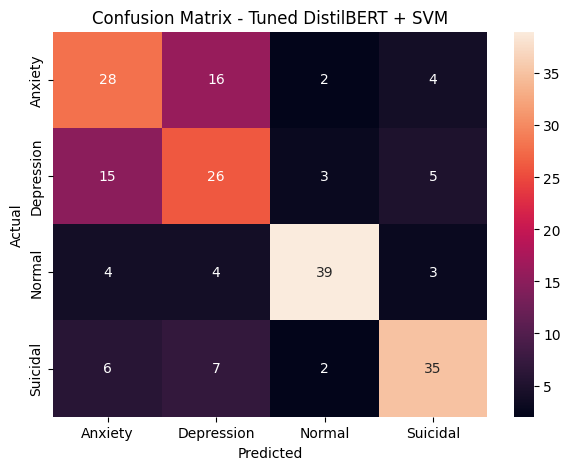

In [93]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_tuned)

plt.figure(figsize=(7,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Tuned DistilBERT + SVM")

plt.show()

In [94]:
from datasets import Dataset

train_data = pd.DataFrame({
    "text": X_train,
    "label": y_train
})

test_data = pd.DataFrame({
    "text": X_test,
    "label": y_test
})


train_dataset = Dataset.from_pandas(train_data)
test_dataset = Dataset.from_pandas(test_data)

print(train_dataset)
print(test_dataset)

Dataset({
    features: ['text', 'label', '__index_level_0__'],
    num_rows: 793
})
Dataset({
    features: ['text', 'label', '__index_level_0__'],
    num_rows: 199
})


In [95]:
def tokenize_function(batch):
    return tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=256
    )


train_dataset = train_dataset.map(
    tokenize_function,
    batched=True
)

test_dataset = test_dataset.map(
    tokenize_function,
    batched=True
)

print(train_dataset)

Map:   0%|          | 0/793 [00:00<?, ? examples/s]

Map:   0%|          | 0/199 [00:00<?, ? examples/s]

Dataset({
    features: ['text', 'label', '__index_level_0__', 'input_ids', 'attention_mask'],
    num_rows: 793
})


In [96]:
from transformers import DistilBertForSequenceClassification

model_ft = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=4
)

print("Fine-tuning model loaded successfully!")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Fine-tuning model loaded successfully!


In [97]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./mental_health_model",
    num_train_epochs=5,
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    warmup_steps=50,
    weight_decay=0.01,
    logging_dir="./logs",
    logging_steps=10,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="accuracy"
)

print("Training arguments created!")

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Training arguments created!


In [98]:
logging_dir="./logs"

In [99]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    
    predictions = logits.argmax(axis=-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="weighted"
    )

    acc = accuracy_score(
        labels,
        predictions
    )

    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

print("Metrics function created!")

Metrics function created!


In [100]:
from transformers import Trainer

trainer = Trainer(
    model=model_ft,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

print("Trainer created successfully!")

Trainer created successfully!


In [104]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.374972,0.629732,0.763819,0.778092,0.763819,0.765834
2,0.415466,0.621287,0.793970,0.809290,0.793970,0.798420
3,0.177205,0.656485,0.793970,0.800000,0.793970,0.788062
4,0.177565,0.680659,0.804020,0.805472,0.804020,0.798276
5,0.039057,0.692343,0.814070,0.816521,0.814070,0.814988


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=500, training_loss=0.26532480639219286, metrics={'train_runtime': 3026.872, 'train_samples_per_second': 1.31, 'train_steps_per_second': 0.165, 'total_flos': 263685761611776.0, 'train_loss': 0.26532480639219286, 'epoch': 5.0})

In [105]:
results = trainer.evaluate()

print(results)

{'eval_loss': 0.6923432350158691, 'eval_accuracy': 0.8140703517587939, 'eval_precision': 0.8165213958499535, 'eval_recall': 0.8140703517587939, 'eval_f1': 0.8149876431917321, 'eval_runtime': 37.6709, 'eval_samples_per_second': 5.283, 'eval_steps_per_second': 0.664, 'epoch': 5.0}


In [106]:
import numpy as np
from sklearn.metrics import accuracy_score, classification_report

predictions = trainer.predict(test_dataset)

y_pred = np.argmax(predictions.predictions, axis=1)
y_true = predictions.label_ids

print("Accuracy:", accuracy_score(y_true, y_pred))

print("\nClassification Report:\n")
print(classification_report(
    y_true,
    y_pred,
    target_names=label_encoder.classes_
))

Accuracy: 0.8140703517587939

Classification Report:

              precision    recall  f1-score   support

     Anxiety       0.79      0.82      0.80        50
  Depression       0.68      0.69      0.69        49
      Normal       0.91      0.86      0.89        50
    Suicidal       0.88      0.88      0.88        50

    accuracy                           0.81       199
   macro avg       0.82      0.81      0.81       199
weighted avg       0.82      0.81      0.81       199



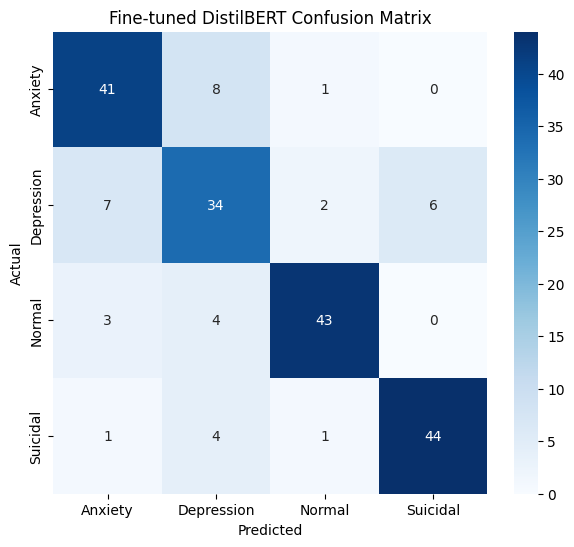

In [107]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Fine-tuned DistilBERT Confusion Matrix")

plt.show()

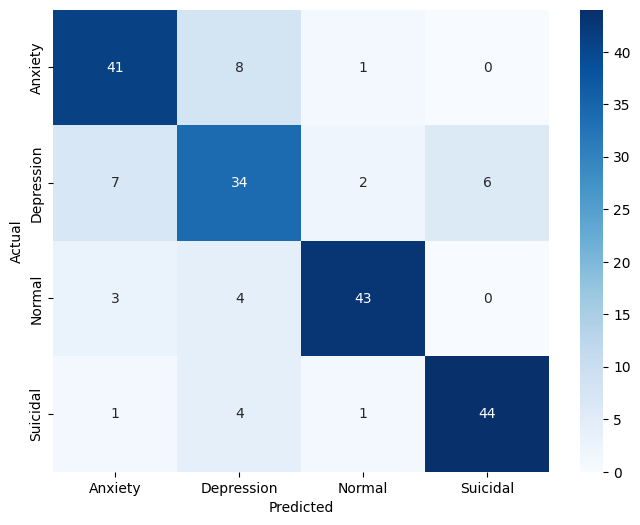

In [108]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [110]:
from transformers import RobertaTokenizer

tokenizer = RobertaTokenizer.from_pretrained(
    "roberta-base"
)

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [111]:
from transformers import RobertaForSequenceClassification

model_ft = RobertaForSequenceClassification.from_pretrained(
    "roberta-base",
    num_labels=4
)

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [112]:
from transformers import RobertaTokenizer

tokenizer = RobertaTokenizer.from_pretrained("roberta-base")

print("Tokenizer Loaded!")

Tokenizer Loaded!


In [113]:
def tokenize(batch):
    return tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=512
    )

train_dataset = train_dataset.map(tokenize, batched=True)
test_dataset = test_dataset.map(tokenize, batched=True)

Map:   0%|          | 0/793 [00:00<?, ? examples/s]

Map:   0%|          | 0/199 [00:00<?, ? examples/s]

In [118]:
trainer = Trainer(
    model=model_ft,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
)

In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss
